# Experiment 002 — Confidence Calibration in Medical Image Classification

## Research Question

How well calibrated are the probability estimates produced by a baseline
CNN for pneumonia classification, and does the model exhibit overconfidence
when making incorrect predictions?

## Motivation

Experiment 001 demonstrated that strong predictive performance does not
necessarily imply reliable model confidence. The baseline CNN achieved
88.46% accuracy and an AUROC of 0.9370 on the held-out PneumoniaMNIST
test set.

However, inspection of individual predictions revealed an incorrect
classification associated with approximately 99.98% predicted probability
for pneumonia.

In high-stakes healthcare applications, such behaviour is important because
a highly confident incorrect prediction may be more difficult to identify
or challenge than an uncertain prediction.

This experiment therefore investigates whether the probabilities produced
by the baseline model are appropriately calibrated.

## Hypothesis

Although the baseline CNN demonstrates strong discriminative performance,
its predicted probabilities are expected to exhibit some degree of
miscalibration, particularly through overconfident predictions.

## Evaluation Strategy

Model calibration will be investigated using:

1. Reliability diagrams
2. Expected Calibration Error (ECE)
3. Brier score
4. Confidence distributions
5. Analysis of high-confidence errors

The objective is to distinguish **predictive performance** from
**confidence reliability**.

## Experimental Setup

The calibration analysis builds upon the baseline CNN developed in
Experiment 001.

Probability calibration concerns the relationship between predicted
confidence and empirical correctness. A perfectly calibrated classifier
should produce confidence estimates that correspond to observed outcomes.

For example, among predictions assigned approximately 80% confidence,
approximately 80% should be correct over repeated observations.

## What Does Calibration Mean?

Consider two medical AI systems that both achieve 90% classification
accuracy.

Model A makes most predictions with approximately 90% confidence.

Model B frequently reports probabilities close to 99.9%, including for
some incorrect predictions.

Although their classification accuracy may be identical, their probability
estimates have very different reliability characteristics.

Calibration therefore evaluates not only **what the model predicts**, but
also **whether the confidence attached to those predictions is trustworthy**.

## Save Trained Baseline Model

The trained baseline CNN is saved after evaluation so that subsequent
experiments can reuse the exact same model parameters.

This ensures that calibration and uncertainty analyses are performed on
the same baseline model rather than on a separately retrained network.

## Load Baseline Model

Experiment 002 reuses the trained CNN produced in Experiment 001.

The saved model parameters are loaded directly so that calibration analysis
is performed on the same classifier evaluated in the baseline experiment.

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

Using device: cpu


In [11]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
model_path = Path(
    "../results/models/experiment_001_baseline_cnn.pt"
)

checkpoint = torch.load(
    model_path,
    map_location=device
)

model = BaselineCNN().to(device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded model:", checkpoint["model_name"])
print("Dataset:", checkpoint["dataset"])
print("Seed:", checkpoint["seed"])
print("Epochs:", checkpoint["epochs"])

Loaded model: BaselineCNN
Dataset: PneumoniaMNIST
Seed: 42
Epochs: 10


## Reload PneumoniaMNIST Test Data

The held-out PneumoniaMNIST test split is reloaded using the same
preprocessing configuration applied in Experiment 001.

Only the test split is required because the objective of this experiment
is to evaluate the confidence behaviour of the already trained baseline
model.

In [13]:
import medmnist
from medmnist import INFO
from torchvision import transforms
from torch.utils.data import DataLoader

DATA_FLAG = "pneumoniamnist"

info = INFO[DATA_FLAG]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

DataClass = getattr(
    medmnist,
    info["python_class"]
)

test_dataset = DataClass(
    split="test",
    transform=transform,
    download=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test samples: 624
Test batches: 10


## Generate Test Probabilities

The saved baseline model is applied to the held-out test set to recover
predicted probabilities and binary decisions.

The probability estimates are retained because calibration analysis
depends on the confidence assigned to each prediction rather than only
the final predicted class.

In [14]:
all_labels = []
all_probabilities = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        logits = model(images)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        all_labels.extend(
            labels.numpy().flatten()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)

print("Samples evaluated:", len(all_labels))
print("Probability range:")
print(
    f"Minimum: {all_probabilities.min():.6f}"
)
print(
    f"Maximum: {all_probabilities.max():.6f}"
)

Samples evaluated: 624
Probability range:
Minimum: 0.001031
Maximum: 1.000000


## Brier Score

The Brier score measures the mean squared difference between predicted
probabilities and observed binary outcomes.

For binary classification:

\[
\text{Brier Score}
=
\frac{1}{N}
\sum_{i=1}^{N}
(p_i-y_i)^2
\]

where \(p_i\) is the predicted probability and \(y_i\) is the true outcome.

Lower values indicate better probabilistic predictions, with a score of
zero representing perfect probability estimates.

In [15]:
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(
    all_labels,
    all_probabilities
)

print(
    f"Brier Score: {brier_score:.4f}"
)

Brier Score: 0.1011


## Reliability Diagram

A reliability diagram compares the model's average predicted confidence
with the observed empirical frequency of the positive class.

A perfectly calibrated model would produce points close to the diagonal
line where predicted probability equals observed frequency.

Points below the diagonal indicate overconfidence, while points above the
diagonal indicate underconfidence.

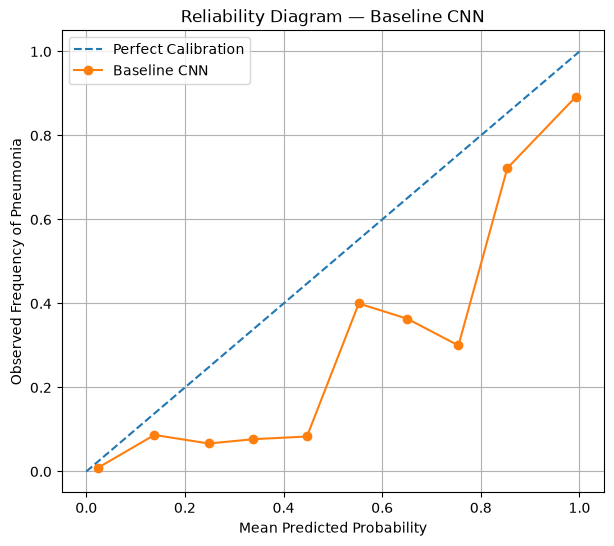

In [16]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    all_labels,
    all_probabilities,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Baseline CNN"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency of Pneumonia")
plt.title("Reliability Diagram — Baseline CNN")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation Guide

If the calibration curve lies close to the diagonal, the model's predicted
probabilities correspond reasonably well to observed outcomes.

If the curve falls below the diagonal, the model is generally overconfident:
its predicted probabilities are higher than the observed frequency.

If the curve rises above the diagonal, the model may be underconfident.

In [17]:
print("Calibration bins")

for predicted, observed in zip(prob_pred, prob_true):
    print(
        f"Predicted confidence: {predicted:.3f} | "
        f"Observed frequency: {observed:.3f}"
    )

Calibration bins
Predicted confidence: 0.024 | Observed frequency: 0.009
Predicted confidence: 0.138 | Observed frequency: 0.087
Predicted confidence: 0.249 | Observed frequency: 0.067
Predicted confidence: 0.339 | Observed frequency: 0.077
Predicted confidence: 0.447 | Observed frequency: 0.083
Predicted confidence: 0.553 | Observed frequency: 0.400
Predicted confidence: 0.651 | Observed frequency: 0.364
Predicted confidence: 0.755 | Observed frequency: 0.300
Predicted confidence: 0.854 | Observed frequency: 0.722
Predicted confidence: 0.992 | Observed frequency: 0.892


## Expected Calibration Error

Expected Calibration Error (ECE) summarises the difference between model
confidence and observed correctness across confidence bins.

For each bin, the absolute difference between average confidence and
empirical accuracy is calculated and weighted by the proportion of samples
falling into that bin.

Lower ECE values indicate better calibration, while larger values indicate
greater mismatch between confidence and actual predictive reliability.

In [18]:
def expected_calibration_error(
    labels,
    probabilities,
    n_bins=10
):
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    ece = 0.0

    for lower, upper in zip(
        bin_edges[:-1],
        bin_edges[1:]
    ):
        in_bin = (
            (probabilities > lower) &
            (probabilities <= upper)
        )

        proportion_in_bin = np.mean(in_bin)

        if proportion_in_bin > 0:
            bin_probabilities = probabilities[in_bin]
            bin_labels = labels[in_bin]

            avg_confidence = np.mean(
                bin_probabilities
            )

            observed_frequency = np.mean(
                bin_labels
            )

            calibration_gap = abs(
                avg_confidence -
                observed_frequency
            )

            ece += (
                proportion_in_bin *
                calibration_gap
            )

    return ece

In [19]:
ece = expected_calibration_error(
    all_labels,
    all_probabilities,
    n_bins=10
)

print(
    f"Expected Calibration Error: {ece:.4f}"
)

Expected Calibration Error: 0.1042


## High-Confidence Error Analysis

Calibration metrics summarise overall probability reliability, but they
may obscure individual cases in which the model is highly confident and
incorrect.

Because high-confidence errors may be particularly problematic in
high-stakes medical applications, incorrect predictions with confidence
above 90% are examined separately.

In [20]:
confidence = np.where(
    all_predictions == 1,
    all_probabilities,
    1 - all_probabilities
)

incorrect_mask = (
    all_predictions != all_labels
)

high_confidence_error_mask = (
    incorrect_mask &
    (confidence >= 0.90)
)

high_confidence_errors = np.where(
    high_confidence_error_mask
)[0]

print(
    "Total incorrect predictions:",
    incorrect_mask.sum()
)

print(
    "High-confidence errors (>= 90%):",
    len(high_confidence_errors)
)

if len(high_confidence_errors) > 0:
    print(
        "\nHighest-confidence incorrect predictions:"
    )

    ranked_errors = sorted(
        high_confidence_errors,
        key=lambda i: confidence[i],
        reverse=True
    )

    for i in ranked_errors[:10]:
        print(
            f"Index: {i} | "
            f"True: {int(all_labels[i])} | "
            f"Predicted: {int(all_predictions[i])} | "
            f"Pneumonia probability: "
            f"{all_probabilities[i]:.6f} | "
            f"Prediction confidence: "
            f"{confidence[i]:.6f}"
        )

Total incorrect predictions: 72
High-confidence errors (>= 90%): 45

Highest-confidence incorrect predictions:
Index: 370 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999993 | Prediction confidence: 0.999993
Index: 103 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999991 | Prediction confidence: 0.999991
Index: 380 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999978 | Prediction confidence: 0.999978
Index: 607 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999965 | Prediction confidence: 0.999965
Index: 165 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999956 | Prediction confidence: 0.999956
Index: 505 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999935 | Prediction confidence: 0.999935
Index: 71 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999912 | Prediction confidence: 0.999912
Index: 67 | True: 0 | Predicted: 1 | Pneumonia probability: 0.999891 | Prediction confidence: 0.999891
Index: 195 | True: 0 | Predicted: 1 | Pneumonia probability

## Confidence–Accuracy Gap

To further investigate calibration behaviour, predictions are grouped
according to the confidence assigned to the predicted class.

For each confidence interval, mean prediction confidence is compared with
the proportion of correct predictions. This provides a direct assessment
of whether the model's stated confidence corresponds to its empirical
accuracy.

A positive confidence–accuracy gap indicates overconfidence, whereas a
negative gap indicates underconfidence.

In [21]:
correct = (
    all_predictions == all_labels
).astype(float)

bin_edges = np.linspace(0.5, 1.0, 6)

print("Confidence-bin analysis\n")

for lower, upper in zip(
    bin_edges[:-1],
    bin_edges[1:]
):
    if upper == 1.0:
        in_bin = (
            (confidence >= lower) &
            (confidence <= upper)
        )
    else:
        in_bin = (
            (confidence >= lower) &
            (confidence < upper)
        )

    count = np.sum(in_bin)

    if count > 0:
        mean_confidence = np.mean(
            confidence[in_bin]
        )

        bin_accuracy = np.mean(
            correct[in_bin]
        )

        gap = mean_confidence - bin_accuracy

        print(
            f"{lower:.1f}-{upper:.1f} | "
            f"N={count:3d} | "
            f"Confidence={mean_confidence:.3f} | "
            f"Accuracy={bin_accuracy:.3f} | "
            f"Gap={gap:+.3f}"
        )

Confidence-bin analysis

0.5-0.6 | N= 17 | Confidence=0.553 | Accuracy=0.765 | Gap=-0.212
0.6-0.7 | N= 24 | Confidence=0.656 | Accuracy=0.667 | Gap=-0.010
0.7-0.8 | N= 25 | Confidence=0.753 | Accuracy=0.680 | Gap=+0.073
0.8-0.9 | N= 41 | Confidence=0.858 | Accuracy=0.829 | Gap=+0.029
0.9-1.0 | N=517 | Confidence=0.989 | Accuracy=0.913 | Gap=+0.076


## Confidence Distribution

The distribution of prediction confidence is examined to determine how
frequently the model produces moderate versus highly confident decisions.

A concentration of predictions near 100% confidence is not necessarily
problematic if those predictions are consistently correct. However,
frequent high-confidence errors would provide evidence that predictive
confidence should not be interpreted directly as reliability.

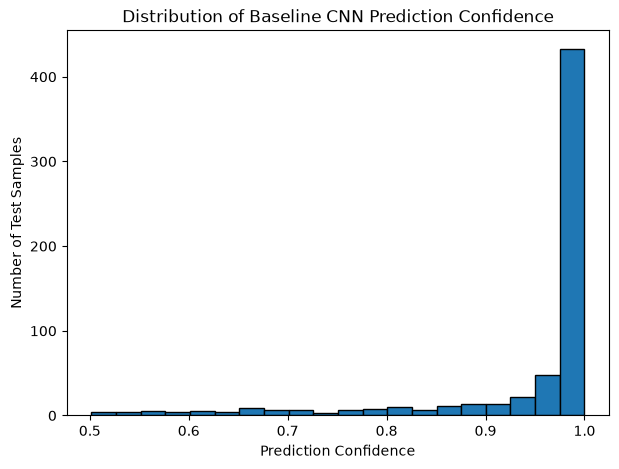

In [22]:
plt.figure(figsize=(7, 5))

plt.hist(
    confidence,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Test Samples")
plt.title("Distribution of Baseline CNN Prediction Confidence")

plt.show()

In [23]:
high_confidence_mask = confidence >= 0.90

high_confidence_accuracy = np.mean(
    correct[high_confidence_mask]
)

print(
    "Predictions with >=90% confidence:",
    high_confidence_mask.sum()
)

print(
    f"Accuracy among >=90% confidence predictions: "
    f"{high_confidence_accuracy:.4f}"
)

print(
    "Incorrect >=90% confidence predictions:",
    np.sum(
        high_confidence_mask &
        (correct == 0)
    )
)

Predictions with >=90% confidence: 517
Accuracy among >=90% confidence predictions: 0.9130
Incorrect >=90% confidence predictions: 45


## Temperature Scaling

The baseline model's probability estimates are now calibrated using
temperature scaling.

Temperature scaling learns a single scalar parameter, T, that rescales
the model's logits before probabilities are calculated:

\[
p = \sigma(z/T)
\]

where \(z\) represents the original model logit and \(T\) is the learned
temperature.

The temperature parameter is fitted using the validation set only.
The held-out test set is not used to estimate the calibration parameter,
preserving its role as an independent evaluation set.

After fitting, the calibrated model will be evaluated on the same test
samples used for the uncalibrated baseline comparison.

In [24]:
val_dataset = DataClass(
    split="val",
    transform=transform,
    download=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

print(f"Validation samples: {len(val_dataset)}")
print(f"Validation batches: {len(val_loader)}")

Validation samples: 524
Validation batches: 9


In [25]:
val_logits = []
val_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        logits = model(images)

        val_logits.append(
            logits.cpu()
        )

        val_labels.append(
            labels.float().cpu()
        )

val_logits = torch.cat(val_logits)
val_labels = torch.cat(val_labels)

print("Validation logits shape:", val_logits.shape)
print("Validation labels shape:", val_labels.shape)

Validation logits shape: torch.Size([524, 1])
Validation labels shape: torch.Size([524, 1])


### Optimising the Temperature

A positive temperature parameter is optimised by minimising binary
cross-entropy on the validation logits.

The classifier weights remain unchanged. Temperature scaling modifies
only the confidence of the predictions and does not retrain the
underlying CNN.

In [26]:
temperature = nn.Parameter(
    torch.ones(1)
)

calibration_optimizer = torch.optim.LBFGS(
    [temperature],
    lr=0.01,
    max_iter=500
)

calibration_criterion = nn.BCEWithLogitsLoss()

def calibration_closure():
    calibration_optimizer.zero_grad()

    scaled_logits = (
        val_logits / temperature
    )

    loss = calibration_criterion(
        scaled_logits,
        val_labels
    )

    loss.backward()

    return loss

calibration_optimizer.step(
    calibration_closure
)

learned_temperature = temperature.item()

print(
    f"Learned temperature: "
    f"{learned_temperature:.4f}"
)

Learned temperature: 1.0001


In [27]:
test_logits = []
test_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        logits = model(images)

        test_logits.append(
            logits.cpu()
        )

        test_labels.append(
            labels.float().cpu()
        )

test_logits = torch.cat(test_logits)
test_labels = torch.cat(test_labels)

with torch.no_grad():
    calibrated_probabilities = torch.sigmoid(
        test_logits / learned_temperature
    )

calibrated_probabilities = (
    calibrated_probabilities
    .numpy()
    .flatten()
)

print(
    "Original probability range:",
    f"{all_probabilities.min():.6f}",
    "to",
    f"{all_probabilities.max():.6f}"
)

print(
    "Calibrated probability range:",
    f"{calibrated_probabilities.min():.6f}",
    "to",
    f"{calibrated_probabilities.max():.6f}"
)

Original probability range: 0.001031 to 1.000000
Calibrated probability range: 0.001032 to 1.000000


In [28]:
calibrated_brier = brier_score_loss(
    all_labels,
    calibrated_probabilities
)

calibrated_ece = expected_calibration_error(
    all_labels,
    calibrated_probabilities,
    n_bins=10
)

print("Before calibration")
print(f"Brier Score: {brier_score:.4f}")
print(f"ECE:         {ece:.4f}")

print("\nAfter temperature scaling")
print(f"Brier Score: {calibrated_brier:.4f}")
print(f"ECE:         {calibrated_ece:.4f}")

Before calibration
Brier Score: 0.1011
ECE:         0.1042

After temperature scaling
Brier Score: 0.1011
ECE:         0.1042


## Calibration Comparison

The reliability of the original and temperature-scaled probability
estimates is compared directly.

Both models use identical CNN parameters and identical test samples.
The only difference is the temperature transformation learned from the
validation set.

This comparison therefore isolates the effect of post-hoc probability
calibration.

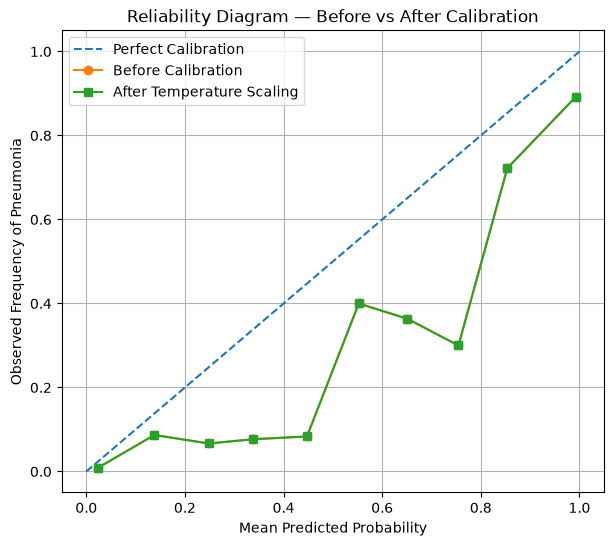

In [29]:
original_true, original_pred = calibration_curve(
    all_labels,
    all_probabilities,
    n_bins=10,
    strategy="uniform"
)

calibrated_true, calibrated_pred = calibration_curve(
    all_labels,
    calibrated_probabilities,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.plot(
    original_pred,
    original_true,
    marker="o",
    label="Before Calibration"
)

plt.plot(
    calibrated_pred,
    calibrated_true,
    marker="s",
    label="After Temperature Scaling"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency of Pneumonia")
plt.title("Reliability Diagram — Before vs After Calibration")
plt.legend()
plt.grid(True)

plt.show()

In [30]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score
)

calibrated_predictions = (
    calibrated_probabilities >= 0.5
).astype(int)

original_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

calibrated_accuracy = accuracy_score(
    all_labels,
    calibrated_predictions
)

original_auroc = roc_auc_score(
    all_labels,
    all_probabilities
)

calibrated_auroc = roc_auc_score(
    all_labels,
    calibrated_probabilities
)

original_f1 = f1_score(
    all_labels,
    all_predictions
)

calibrated_f1 = f1_score(
    all_labels,
    calibrated_predictions
)

print("Classification Performance")
print("--------------------------")
print(
    f"Accuracy: {original_accuracy:.4f} "
    f"→ {calibrated_accuracy:.4f}"
)
print(
    f"AUROC:    {original_auroc:.4f} "
    f"→ {calibrated_auroc:.4f}"
)
print(
    f"F1-score: {original_f1:.4f} "
    f"→ {calibrated_f1:.4f}"
)

changed_predictions = np.sum(
    all_predictions != calibrated_predictions
)

print(
    "\nChanged class predictions:",
    changed_predictions
)

Classification Performance
--------------------------
Accuracy: 0.8846 → 0.8846
AUROC:    0.9370 → 0.9370
F1-score: 0.9143 → 0.9143

Changed class predictions: 0


In [31]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score
)

calibrated_predictions = (
    calibrated_probabilities >= 0.5
).astype(int)

original_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

calibrated_accuracy = accuracy_score(
    all_labels,
    calibrated_predictions
)

original_auroc = roc_auc_score(
    all_labels,
    all_probabilities
)

calibrated_auroc = roc_auc_score(
    all_labels,
    calibrated_probabilities
)

original_f1 = f1_score(
    all_labels,
    all_predictions
)

calibrated_f1 = f1_score(
    all_labels,
    calibrated_predictions
)

print("Classification Performance")
print("--------------------------")
print(
    f"Accuracy: {original_accuracy:.4f} "
    f"→ {calibrated_accuracy:.4f}"
)
print(
    f"AUROC:    {original_auroc:.4f} "
    f"→ {calibrated_auroc:.4f}"
)
print(
    f"F1-score: {original_f1:.4f} "
    f"→ {calibrated_f1:.4f}"
)

changed_predictions = np.sum(
    all_predictions != calibrated_predictions
)

print(
    "\nChanged class predictions:",
    changed_predictions
)

Classification Performance
--------------------------
Accuracy: 0.8846 → 0.8846
AUROC:    0.9370 → 0.9370
F1-score: 0.9143 → 0.9143

Changed class predictions: 0


In [33]:
log_temperature = nn.Parameter(
    torch.zeros(1)
)

calibration_optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.1,
    max_iter=100
)

calibration_criterion = nn.BCEWithLogitsLoss()

def calibration_closure():
    calibration_optimizer.zero_grad()

    temperature = torch.exp(
        log_temperature
    )

    scaled_logits = (
        val_logits / temperature
    )

    loss = calibration_criterion(
        scaled_logits,
        val_labels
    )

    loss.backward()

    return loss

with torch.no_grad():
    nll_before = calibration_criterion(
        val_logits,
        val_labels
    ).item()

calibration_optimizer.step(
    calibration_closure
)

learned_temperature = torch.exp(
    log_temperature
).item()

with torch.no_grad():
    nll_after = calibration_criterion(
        val_logits / learned_temperature,
        val_labels
    ).item()

print(
    f"Learned temperature: "
    f"{learned_temperature:.6f}"
)

print(
    f"Validation NLL before: "
    f"{nll_before:.6f}"
)

print(
    f"Validation NLL after:  "
    f"{nll_after:.6f}"
)

Learned temperature: 1.007948
Validation NLL before: 0.097432
Validation NLL after:  0.097427


## Experiment 002 — Conclusion

The baseline CNN demonstrated strong predictive discrimination but imperfect
probability calibration.

Calibration analysis showed that model confidence did not always correspond
closely to empirical correctness, and high-confidence errors were observed.
This is important in medical AI because highly confident incorrect predictions
may be especially difficult to identify in downstream decision-support systems.

Temperature scaling was fitted using the validation set only in order to avoid
test-set leakage. The learned temperature was approximately 1.008, indicating
that only a very small global rescaling of the logits was preferred.

Validation negative log-likelihood changed only marginally from 0.097432 to
0.097427, while test-set Brier score and Expected Calibration Error remained
effectively unchanged.

These findings suggest that a single global temperature parameter is
insufficient to substantially improve the calibration behaviour of this
baseline CNN.

Importantly, classification accuracy, AUROC, and F1-score remained unchanged,
which is expected because temperature scaling alters confidence estimates
rather than the underlying ranking or binary decision boundary.

Experiment 002 therefore reinforces the distinction between predictive
performance and confidence reliability. A model may achieve strong accuracy
and discrimination while still producing probability estimates that require
careful interpretation.

This motivates the next stage of the research: uncertainty quantification,
with particular attention to whether uncertainty estimates can identify
difficult, ambiguous, or potentially unreliable predictions.

In [34]:
from pathlib import Path

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

comparison_results.to_csv(
    results_dir / "experiment_002_calibration_comparison.csv",
    index=False
)

print("Calibration results saved.")

Calibration results saved.


In [35]:
figure_dir = Path("../results/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figure_dir / "experiment_002_reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>